In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Absenteeism_at_work.csv', sep=';')
print("Shape :", df.shape)
df.head()

Shape : (740, 21)


,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,...,Disciplinary failure,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours
0,11,26,7,3,1,289,36,13,33,239.554,...,0,1,2,1,0,1,90,172,30,4
1,36,0,7,3,1,118,13,18,50,239.554,...,1,1,1,1,0,0,98,178,31,0
2,3,23,7,4,1,179,51,18,38,239.554,...,0,1,0,1,0,0,89,170,31,2
3,7,7,7,5,1,279,5,14,39,239.554,...,0,1,2,1,1,0,68,168,24,4
4,11,23,7,5,1,289,36,13,33,239.554,...,0,1,2,1,0,1,90,172,30,2


In [2]:
# Vérification qualité des données
print("Valeurs manquantes :", df.isnull().sum().sum())
print("\nDoublons :", df.duplicated().sum())
print("\nColonnes et types :")
print(df.dtypes)

Valeurs manquantes : 0

Doublons : 34

Colonnes et types :
ID                                   int64
Reason for absence                   int64
Month of absence                     int64
Day of the week                      int64
Seasons                              int64
Transportation expense               int64
Distance from Residence to Work      int64
Service time                         int64
Age                                  int64
Work load Average/day              float64
Hit target                           int64
Disciplinary failure                 int64
Education                            int64
Son                                  int64
Social drinker                       int64
Social smoker                        int64
Pet                                  int64
Weight                               int64
Height                               int64
Body mass index                      int64
Absenteeism time in hours            int64
dtype: object


Absence_longue
0    0.541892
1    0.458108
Name: proportion, dtype: float64


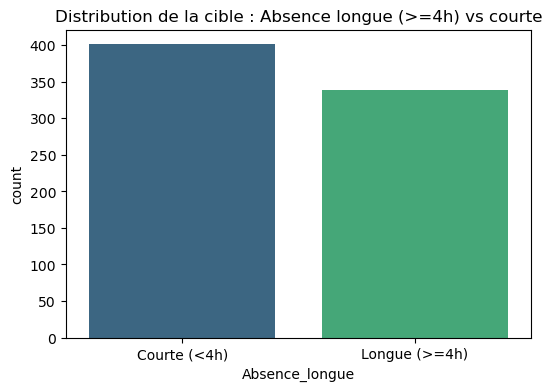

In [3]:
# Création de la variable cible
# Absentéisme "long" (>= 4h) vs "court" (< 4h) -- seuil qui donne un split quasi équilibré
df['Absence_longue'] = (df['Absenteeism time in hours'] >= 4).astype(int)

print(df['Absence_longue'].value_counts(normalize=True))

plt.figure(figsize=(6,4))
sns.countplot(x='Absence_longue', data=df, hue='Absence_longue', palette='viridis', legend=False)
plt.title("Distribution de la cible : Absence longue (>=4h) vs courte")
plt.xticks([0,1], ['Courte (<4h)', 'Longue (>=4h)'])
plt.show()

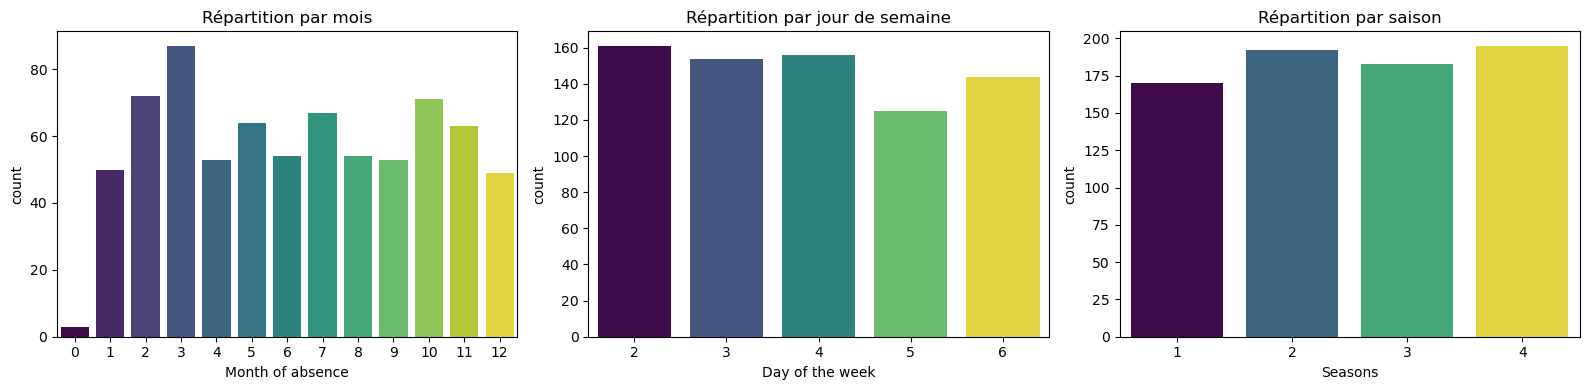

In [4]:
#Distribution des variables temporelles
fig, axes = plt.subplots(1, 3, figsize=(16,4))

sns.countplot(x='Month of absence', data=df, ax=axes[0], hue='Month of absence', palette='viridis', legend=False)
axes[0].set_title("Répartition par mois")

sns.countplot(x='Day of the week', data=df, ax=axes[1], hue='Day of the week', palette='viridis', legend=False)
axes[1].set_title("Répartition par jour de semaine")

sns.countplot(x='Seasons', data=df, ax=axes[2], hue='Seasons', palette='viridis', legend=False)
axes[2].set_title("Répartition par saison")

plt.tight_layout()
plt.show()

In [5]:
# Corrélations avec la cible
correlations = df.drop(['ID', 'Absenteeism time in hours'], axis=1).corr()['Absence_longue'].sort_values(ascending=False)
print(correlations)

Absence_longue                     1.000000
Transportation expense             0.246761
Son                                0.223815
Social drinker                     0.134648
Month of absence                   0.066388
Height                             0.061639
Work load Average/day              0.041579
Pet                                0.029080
Social smoker                      0.023590
Distance from Residence to Work    0.009341
Weight                             0.008867
Body mass index                   -0.025024
Hit target                        -0.027488
Education                         -0.028023
Age                               -0.037933
Service time                      -0.074167
Seasons                           -0.086945
Day of the week                   -0.101446
Reason for absence                -0.182570
Disciplinary failure              -0.219790
Name: Absence_longue, dtype: float64


In [6]:
# --- INGÉNIERIE TEMPORELLE ---
# Objectif : transformer les variables temporelles brutes en features plus riches et exploitables

# 1. Encodage cyclique du mois (le modèle doit comprendre que décembre et janvier sont proches)
df['Month_sin'] = np.sin(2 * np.pi * df['Month of absence'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month of absence'] / 12)

# 2. Encodage cyclique du jour de la semaine (2=lundi ... 6=vendredi dans ce dataset)
df['Day_sin'] = np.sin(2 * np.pi * df['Day of the week'] / 7)
df['Day_cos'] = np.cos(2 * np.pi * df['Day of the week'] / 7)

# 3. Variable binaire : est-ce un lundi ou un vendredi ? (jours classiques d'absentéisme "de confort")
df['Debut_ou_fin_semaine'] = df['Day of the week'].isin([2, 6]).astype(int)

# 4. Variable binaire : saison hivernale/été (regroupement simplifié)
# Seasons : 1=été, 2=automne, 3=hiver, 4=printemps (selon documentation UCI, hémisphère sud - Brésil)
df['Saison_ete'] = (df['Seasons'] == 1).astype(int)

print(df[['Month of absence', 'Month_sin', 'Month_cos', 'Day of the week', 'Day_sin', 'Day_cos', 'Debut_ou_fin_semaine', 'Saison_ete']].head())

   Month of absence  Month_sin  Month_cos  Day of the week   Day_sin  \
0                 7       -0.5  -0.866025                3  0.433884   
1                 7       -0.5  -0.866025                3  0.433884   
2                 7       -0.5  -0.866025                4 -0.433884   
3                 7       -0.5  -0.866025                5 -0.974928   
4                 7       -0.5  -0.866025                5 -0.974928   

    Day_cos  Debut_ou_fin_semaine  Saison_ete  
0 -0.900969                     0           1  
1 -0.900969                     0           1  
2 -0.900969                     0           1  
3 -0.222521                     0           1  
4 -0.222521                     0           1  


In [7]:
# --- ENCODAGE AVANCÉ DES CATÉGORIES ---
from sklearn.model_selection import train_test_split

# Séparation features / cible AVANT tout encodage basé sur la cible (éviter le data leakage)
colonnes_a_exclure = ['ID', 'Absenteeism time in hours', 'Absence_longue',
                       'Month of absence', 'Day of the week', 'Seasons']  # remplacées par les versions enrichies

X = df.drop(columns=colonnes_a_exclure)
y = df['Absence_longue']

# Split stratifié AVANT le target encoding
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train :", X_train.shape, "| Test :", X_test.shape)
print("Répartition cible train :", y_train.mean())
print("Répartition cible test  :", y_test.mean())

Train : (592, 22) | Test : (148, 22)
Répartition cible train : 0.4577702702702703
Répartition cible test  : 0.4594594594594595


In [8]:
# Target encoding de "Reason for absence" -- calculé UNIQUEMENT sur le train
moyenne_globale = y_train.mean()
target_encoding_map = X_train.join(y_train).groupby('Reason for absence')[y_train.name].mean()

X_train['Reason_encoded'] = X_train['Reason for absence'].map(target_encoding_map)
X_test['Reason_encoded'] = X_test['Reason for absence'].map(target_encoding_map).fillna(moyenne_globale)
# fillna : sécurité si le test contient une catégorie absente du train

# On garde aussi la variable catégorielle brute en parallèle pour comparaison ultérieure si besoin
print(X_train[['Reason for absence', 'Reason_encoded']].drop_duplicates().sort_values('Reason for absence').head(10))

     Reason for absence  Reason_encoded
276                   0        0.000000
299                   1        1.000000
364                   3        1.000000
345                   4        0.500000
455                   5        1.000000
269                   6        0.800000
96                    7        0.714286
268                   8        0.600000
536                   9        1.000000
709                  10        0.952381


In [9]:
# Vérification rapide : quelles colonnes restent catégorielles à faible cardinalité (one-hot possible sans problème)
for col in ['Education', 'Disciplinary failure', 'Social drinker', 'Social smoker']:
    print(col, ":", X_train[col].nunique(), "valeurs uniques")

Education : 4 valeurs uniques
Disciplinary failure : 2 valeurs uniques
Social drinker : 2 valeurs uniques
Social smoker : 2 valeurs uniques


In [10]:
# --- TARGET ENCODING AVEC LISSAGE (plus robuste aux catégories rares) ---
def target_encoding_lisse(train_df, y_train, colonne, poids_lissage=10):
    """
    Calcule un target encoding lissé : les catégories avec peu d'exemples
    sont tirées vers la moyenne globale, évitant le surapprentissage.
    """
    stats = train_df.join(y_train.rename('target')).groupby(colonne)['target'].agg(['mean', 'count'])
    moyenne_globale = y_train.mean()

    # Formule de lissage : plus une catégorie a peu d'exemples, plus elle est tirée vers la moyenne globale
    stats['encoded'] = (stats['mean'] * stats['count'] + moyenne_globale * poids_lissage) / (stats['count'] + poids_lissage)

    return stats['encoded'], moyenne_globale

encoding_map, moyenne_globale = target_encoding_lisse(X_train, y_train, 'Reason for absence', poids_lissage=10)

X_train['Reason_encoded'] = X_train['Reason for absence'].map(encoding_map)
X_test['Reason_encoded'] = X_test['Reason for absence'].map(encoding_map).fillna(moyenne_globale)

print(pd.DataFrame({'brut': X_train['Reason for absence'], 'encoded': X_train['Reason_encoded']}).drop_duplicates().sort_values('brut').head(10))

     brut   encoded
276     0  0.101727
299     1  0.774071
364     3  0.507064
345     4  0.464809
455     5  0.507064
269     6  0.571847
96      7  0.607404
268     8  0.505180
536     9  0.612693
709    10  0.792829


In [11]:
X_train = pd.get_dummies(X_train, columns=['Education'], prefix='Education', drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Education'], prefix='Education', drop_first=True)

# Sécurité : s'assurer que train et test ont exactement les mêmes colonnes après le one-hot
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(X_train.shape, X_test.shape)
print([c for c in X_train.columns if 'Education' in c])

(592, 25) (148, 25)
['Education_2', 'Education_3', 'Education_4']


In [12]:
# --- SÉLECTION DE VARIABLES ---
# On retire "Reason for absence" brut (remplacé par sa version encodée) pour éviter la redondance
X_train_final = X_train.drop(columns=['Reason for absence'])
X_test_final = X_test.drop(columns=['Reason for absence'])

print("Colonnes finales :", X_train_final.columns.tolist())
print("Nombre de features :", X_train_final.shape[1])

Colonnes finales : ['Transportation expense', 'Distance from Residence to Work', 'Service time', 'Age', 'Work load Average/day ', 'Hit target', 'Disciplinary failure', 'Son', 'Social drinker', 'Social smoker', 'Pet', 'Weight', 'Height', 'Body mass index', 'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos', 'Debut_ou_fin_semaine', 'Saison_ete', 'Reason_encoded', 'Education_2', 'Education_3', 'Education_4']
Nombre de features : 24


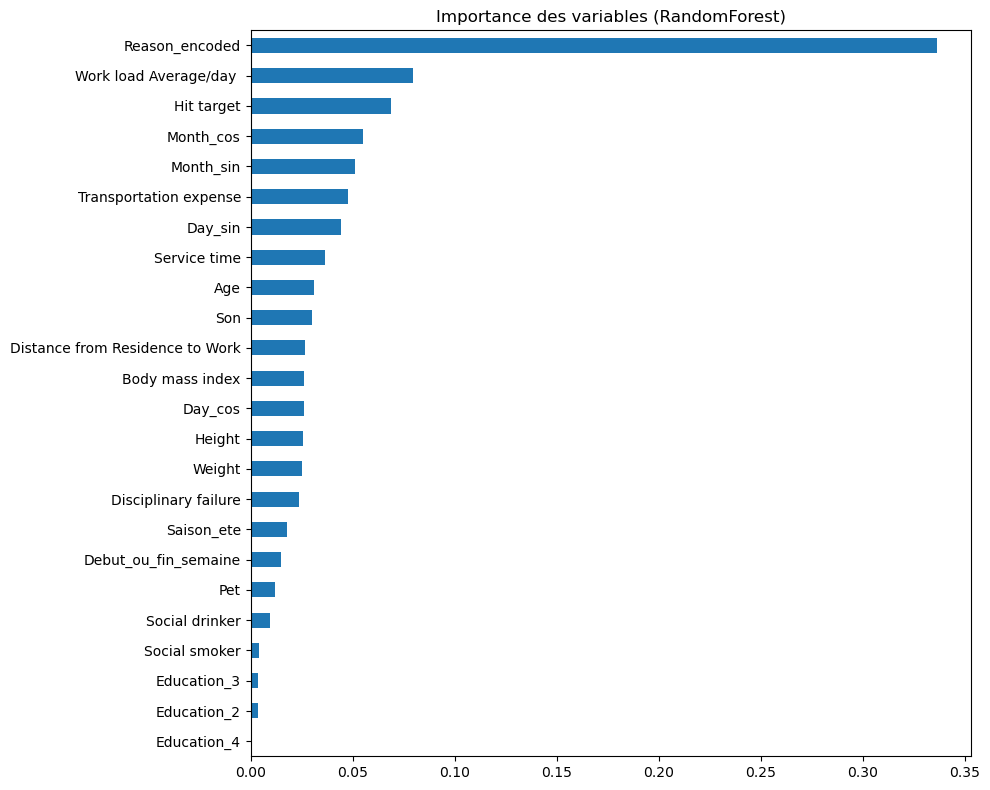

Reason_encoded                     0.336236
Work load Average/day              0.079804
Hit target                         0.069031
Month_cos                          0.054878
Month_sin                          0.051332
Transportation expense             0.047578
Day_sin                            0.044504
Service time                       0.036377
Age                                0.030886
Son                                0.029928
Distance from Residence to Work    0.026762
Body mass index                    0.026193
Day_cos                            0.026114
Height                             0.025796
Weight                             0.025189
Disciplinary failure               0.023680
Saison_ete                         0.018020
Debut_ou_fin_semaine               0.014920
Pet                                0.011900
Social drinker                     0.009650
Social smoker                      0.003977
Education_3                        0.003685
Education_2                     

In [13]:
# Feature importance via RandomForest (méthode robuste, gère bien les interactions non-linéaires)
from sklearn.ensemble import RandomForestClassifier

rf_selection = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_selection.fit(X_train_final, y_train)

importances = pd.Series(rf_selection.feature_importances_, index=X_train_final.columns).sort_values(ascending=False)

plt.figure(figsize=(10,8))
importances.plot(kind='barh')
plt.title("Importance des variables (RandomForest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importances)

In [14]:
# Sélection : on garde les variables dont l'importance cumulée atteint 90%
importance_cumulee = importances.cumsum() / importances.sum()
n_variables_90pct = (importance_cumulee <= 0.90).sum() + 1

variables_selectionnees = importances.head(n_variables_90pct).index.tolist()
print(f"\n{n_variables_90pct} variables sélectionnées pour 90% de l'importance cumulée :")
print(variables_selectionnees)


15 variables sélectionnées pour 90% de l'importance cumulée :
['Reason_encoded', 'Work load Average/day ', 'Hit target', 'Month_cos', 'Month_sin', 'Transportation expense', 'Day_sin', 'Service time', 'Age', 'Son', 'Distance from Residence to Work', 'Body mass index', 'Day_cos', 'Height', 'Weight']


In [15]:
# --- PRÉPARATION DES DATASETS RÉDUITS (variables sélectionnées) ---
X_train_selected = X_train_final[variables_selectionnees]
X_test_selected = X_test_final[variables_selectionnees]

print(X_train_selected.shape, X_test_selected.shape)

(592, 15) (148, 15)


In [16]:
# --- MODÈLE 1 : Logistic Regression ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# La régression logistique est sensible à l'échelle -> on standardise
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_log))
print("Accuracy :", accuracy_score(y_test, y_pred_log))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.81      0.78      0.79        80
           1       0.75      0.78      0.76        68

    accuracy                           0.78       148
   macro avg       0.78      0.78      0.78       148
weighted avg       0.78      0.78      0.78       148

Accuracy : 0.777027027027027


In [17]:
# --- MODÈLE 3 : XGBoost ---
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=300, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_selected, y_train)

y_pred_xgb = xgb_model.predict(X_test_selected)
print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.82      0.78      0.79        80
           1       0.75      0.79      0.77        68

    accuracy                           0.78       148
   macro avg       0.78      0.78      0.78       148
weighted avg       0.79      0.78      0.78       148

Accuracy : 0.7837837837837838


In [18]:
# --- MODÈLE 2 : RandomForest ---
rf_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_model.fit(X_train_selected, y_train)

y_pred_rf = rf_model.predict(X_test_selected)
print("=== RandomForest ===")
print(classification_report(y_test, y_pred_rf))
print("Accuracy :", accuracy_score(y_test, y_pred_rf))

=== RandomForest ===
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        80
           1       0.77      0.78      0.77        68

    accuracy                           0.79       148
   macro avg       0.79      0.79      0.79       148
weighted avg       0.79      0.79      0.79       148

Accuracy : 0.7905405405405406


In [19]:
# --- FUSION DE MODÈLES : STACKING ---
from sklearn.ensemble import StackingClassifier

# Les modèles de base doivent être "frais" (non pré-entraînés) pour que StackingClassifier
# gère correctement la validation croisée interne et évite le data leakage
estimateurs_base = [
    ('log_reg', LogisticRegression(max_iter=1000, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(n_estimators=300, random_state=42, eval_metric='logloss'))
]

# Méta-modèle : une régression logistique simple, standard pour le Stacking
stacking_model = StackingClassifier(
    estimators=estimateurs_base,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5  # validation croisée interne pour générer les prédictions "out-of-fold" des modèles de base
)

# Attention : Logistic Regression dans le Stacking a besoin de données standardisées comme les autres,
# donc on utilise X_train_scaled pour la cohérence -- mais RF/XGBoost n'en ont pas besoin.
# StackingClassifier applique le même X à tous les estimateurs de base, donc on standardise tout.
stacking_model.fit(X_train_scaled, y_train)

y_pred_stacking = stacking_model.predict(X_test_scaled)

print("=== Stacking (Logistic Regression + RandomForest + XGBoost) ===")
print(classification_report(y_test, y_pred_stacking))
print("Accuracy :", accuracy_score(y_test, y_pred_stacking))

=== Stacking (Logistic Regression + RandomForest + XGBoost) ===
              precision    recall  f1-score   support

           0       0.79      0.78      0.78        80
           1       0.74      0.76      0.75        68

    accuracy                           0.77       148
   macro avg       0.77      0.77      0.77       148
weighted avg       0.77      0.77      0.77       148

Accuracy : 0.7702702702702703


In [20]:
# --- COMPARAISON FINALE ---
resultats = {
    'Logistic Regression': accuracy_score(y_test, y_pred_log),
    'RandomForest': accuracy_score(y_test, y_pred_rf),
    'XGBoost': accuracy_score(y_test, y_pred_xgb),
    'Stacking': accuracy_score(y_test, y_pred_stacking)
}

for nom, acc in resultats.items():
    print(f"{nom:25s} : {acc:.4f}")

Logistic Regression       : 0.7770
RandomForest              : 0.7905
XGBoost                   : 0.7838
Stacking                  : 0.7703


In [21]:
import joblib

joblib.dump(rf_model, 'model_absenteisme_rf.pkl')
joblib.dump(encoding_map, 'reason_encoding_map.pkl')
joblib.dump(moyenne_globale, 'moyenne_globale_reason.pkl')
joblib.dump(variables_selectionnees, 'variables_selectionnees.pkl')

print("Modèle et pipeline sauvegardés.")
print("Variables attendues par le modèle :", variables_selectionnees)

Modèle et pipeline sauvegardés.
Variables attendues par le modèle : ['Reason_encoded', 'Work load Average/day ', 'Hit target', 'Month_cos', 'Month_sin', 'Transportation expense', 'Day_sin', 'Service time', 'Age', 'Son', 'Distance from Residence to Work', 'Body mass index', 'Day_cos', 'Height', 'Weight']
